# Optimizing Bank Telemarketing: Multi-Classifier Analysis of Campaign Data


## Overview

**Optimizing Bank Telemarketing: Multi-Classifier Analysis of Campaign Data** applies the CRISP-DM framework to compare KNN, Logistic Regression, Decision Trees, and SVM on the UCI Bank Marketing dataset (41,188 Portuguese telemarketing campaigns, 2008-2010). 

Through business understanding, data preparation, modeling, evaluation, and deployment recommendations, this analysis predicts term deposit subscriptions using client demographics, campaign contacts, and macroeconomic indicators, identifying optimal classifiers to cut wasted calls and boost ~11% baseline conversions. 

The Jupyter Notebook delivers actionable insights for targeted banking outreach.

## 1. Business Understanding

### 1.1 Business Objectives

**Background**: Portuguese bank running telemarketing campaigns (2008-2010) to promote term deposit subscriptions, achieving only ~11% baseline conversion from 41K+ calls.

**Primary Objective**: Predict which clients will subscribe to term deposits using client demographics, campaign history, and macroeconomic indicators—enabling targeted outreach over mass calling.

**Related Questions**: Which client segments (age, job, economic context) show highest uptake? How do contact timing and past campaign outcomes influence success?

**Success Criteria**: Identify top-performing classifier (KNN, Logistic Regression, Decision Trees, SVM) that cuts wasted calls by 20-30% while maintaining >85% prediction accuracy on holdout data.

### 1.2 Assess Situation

This project leverages the public UCI Bank Marketing dataset (41K+ anonymized Portuguese telemarketing records) and standard Python tools (pandas, scikit-learn, Jupyter) for offline classifier comparison—no live bank data access. 

**Requirements & Assumptions**: Complete within academic deadline (Jupyter notebook submission); models must be interpretable for business stakeholders; data legally usable as public research resource. Assumes historical campaigns (2008-2010) patterns hold for modern targeting, with "duration" feature discarded for realistic prediction. 

**Constraints**: Fixed 20-feature dataset limits scope; no real-time deployment; computational focus on tuning 4 classifiers (KNN, Logistic Regression, Decision Trees, SVM) only.

**Risks & Contingencies**: Risk of class imbalance skewing results—mitigate via SMOTE/stratification; poor model generalization—use cross-validation; outdated economic context—note limitations in recommendations.

**Terminology**: Term deposit (long-term savings product); pdays (days since last contact, 999=never); euribor3m (Eurozone interest rate indicator); y (binary target: subscription yes/no).

**Costs & Benefits**: Minimal cost (open-source tools); benefits include 20-30% potential reduction in wasted calls (from ~89% non-conversion baseline), improving bank marketing ROI via targeted outreach.

### 1.3 Data Mining Goals

**Data Mining Goals**: Construct and compare binary classifiers (KNN, Logistic Regression, Decision Trees, SVM) to predict term deposit subscription (y: yes/no) using 20 client, campaign, and macroeconomic features from 41K UCI Bank Marketing records—excluding call duration for realistic pre-call prediction.

**Success Criteria**: Select top classifier with ≥85% accuracy, ≥0.45 AUC-ROC on stratified cross-validation; achieve 20-30% lift over 11% baseline conversion rate; deliver feature importance rankings and confusion matrix for business interpretability.

### 1.4 Project Plan

**Stages**:
1. **Data Understanding** (2h): Load UCI dataset, explore 41K records, check class imbalance (~11% yes).
2. **Data Preparation** (4h): Clean categoricals, encode features, exclude 'duration', split train/test.
3. **Modeling** (5h): Build/train KNN, Logistic Regression, Decision Tree, SVM classifiers.
4. **Evaluation** (3h): Cross-validate accuracy/AUC/F1, compare performance, extract feature importance.
5. **Deployment** (1h): Document insights/recommendations in notebook.

**Tools**: Jupyter Notebook, scikit-learn, pandas (from starter files).

**Risks**: Imbalanced data → Use stratified sampling. Poor convergence → Default to Logistic Regression baseline.

**Review Points**: After modeling, check if top classifier beats 80% accuracy; iterate prep if needed.

## 2. Data Understanding

### 2.1 Collect Initial Data

**Dataset Acquired**: UCI Bank Marketing dataset (`bank-additional-full.csv`, 41,188 records)

**Method**: Downloaded zip, loaded via pandas `read_csv(sep=';')` in Jupyter Notebook (scikit-learn starter environment).

**Issues**: None encountered. File loaded cleanly with 20 input features + binary target (`y`: yes/no term deposit subscription). Ready for exploration.

### 2.2 Describe Data

**Dataset**: `bank-additional-full.csv` - 41,188 records × 21 columns (20 inputs + 1 target).

**Format**: CSV (semicolon-separated), mix of numeric (age, campaign, pdays) and categorical (job, marital, education, etc.) features.

**Key Fields**: Client data (age, job, loans), campaign details (contacts, month, pdays=999 for no prior contact), 5 macroeconomic indicators (euribor3m, cons.conf.idx), target `y` (yes/no term deposit).

**Quality Check**: Clean load, "unknown" labels for missing categoricals, ~11% positive class imbalance. Meets requirements for classifier comparison.

In [88]:
# Imports

import time, warnings, math
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.metrics import confusion_matrix,classification_report
from sklearn.metrics import RocCurveDisplay
from sklearn.metrics import precision_recall_curve
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import PrecisionRecallDisplay
import time
from sklearn.metrics import f1_score
from sklearn.metrics import average_precision_score
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from imblearn.over_sampling import SMOTE
from sklearn.metrics import log_loss, make_scorer
from sklearn.compose import make_column_transformer
from imblearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import roc_auc_score
from sklearn import metrics
from sklearn.dummy import DummyClassifier
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_validate
from sklearn.model_selection import RepeatedKFold
from sklearn.metrics import roc_curve, auc, roc_auc_score
from sklearn.naive_bayes import GaussianNB
from sklearn.naive_bayes import MultinomialNB
from sklearn.preprocessing import MinMaxScaler 
from sklearn import tree
from sklearn.tree import export_graphviz
from sklearn.inspection import permutation_importance
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import HalvingGridSearchCV
from sklearn.utils import resample

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

In [89]:
# Load data from CSV

# Bank-additional-full.csv with all examples (41188) and 20 inputs.
df = pd.read_csv('data/bank-additional-full.csv', sep = ';')
print(f"Number of (records, columns): {df.shape}") 

# Dank-additional.csv with 10% of the examples (4119), randomly selected from 1), and 20 inputs.
# Used in the improved SVM model due to the computational requirements.
df2 = pd.read_csv('data/bank-additional.csv', sep = ';')
print(f"Number of (records, columns) in random dataset: {df2.shape}") 

Number of (records, columns): (41188, 21)
Number of (records, columns) in random dataset: (4119, 21)


In [90]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [91]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [92]:
# Quick statistics overview
df.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


In [93]:
# Target variable check
print("\nTarget distribution:\n", df['y'].value_counts(normalize=True))

# Missing values
df.isnull().sum()


Target distribution:
 y
no     0.887346
yes    0.112654
Name: proportion, dtype: float64


age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

In [94]:
# "unknown" values
print("\nUnknown values:\n", df.isin(['unknown']).sum())


Unknown values:
 age                  0
job                330
marital             80
education         1731
default           8597
housing            990
loan               990
contact              0
month                0
day_of_week          0
duration             0
campaign             0
pdays                0
previous             0
poutcome             0
emp.var.rate         0
cons.price.idx       0
cons.conf.idx        0
euribor3m            0
nr.employed          0
y                    0
dtype: int64


In [95]:
# Duplicates 
df.duplicated().sum()

np.int64(12)

In [96]:
# Unique target values
df['y'].unique()

array(['no', 'yes'], dtype=object)

In [97]:
# Target value counts
df['y'].value_counts()

y
no     36548
yes     4640
Name: count, dtype: int64

#### Describe Data - Key Findings

**Dataset Overview**:
- **41,188 full records** × 21 columns (vs 4,119 sample); **no missing values**, perfect data quality
- **11 categorical** (job, marital, etc.) + **10 numeric** features + binary target `y`

**Data Quality**:
- **12 duplicates** → Drop before modeling
- **"Unknown" labels**: Default (21%), education (4%), job/marital low → Treat as separate category
- **Clean numeric stats**: No outliers needing immediate winsorizing

### 2.3 Explore Data

TARGET: 88.7% NO (36,548) vs 11.3% YES (4,640)
Age - All: 40±10, Subscribers: 41±14
pdays=999 (never contacted): 96.3% (39,673)


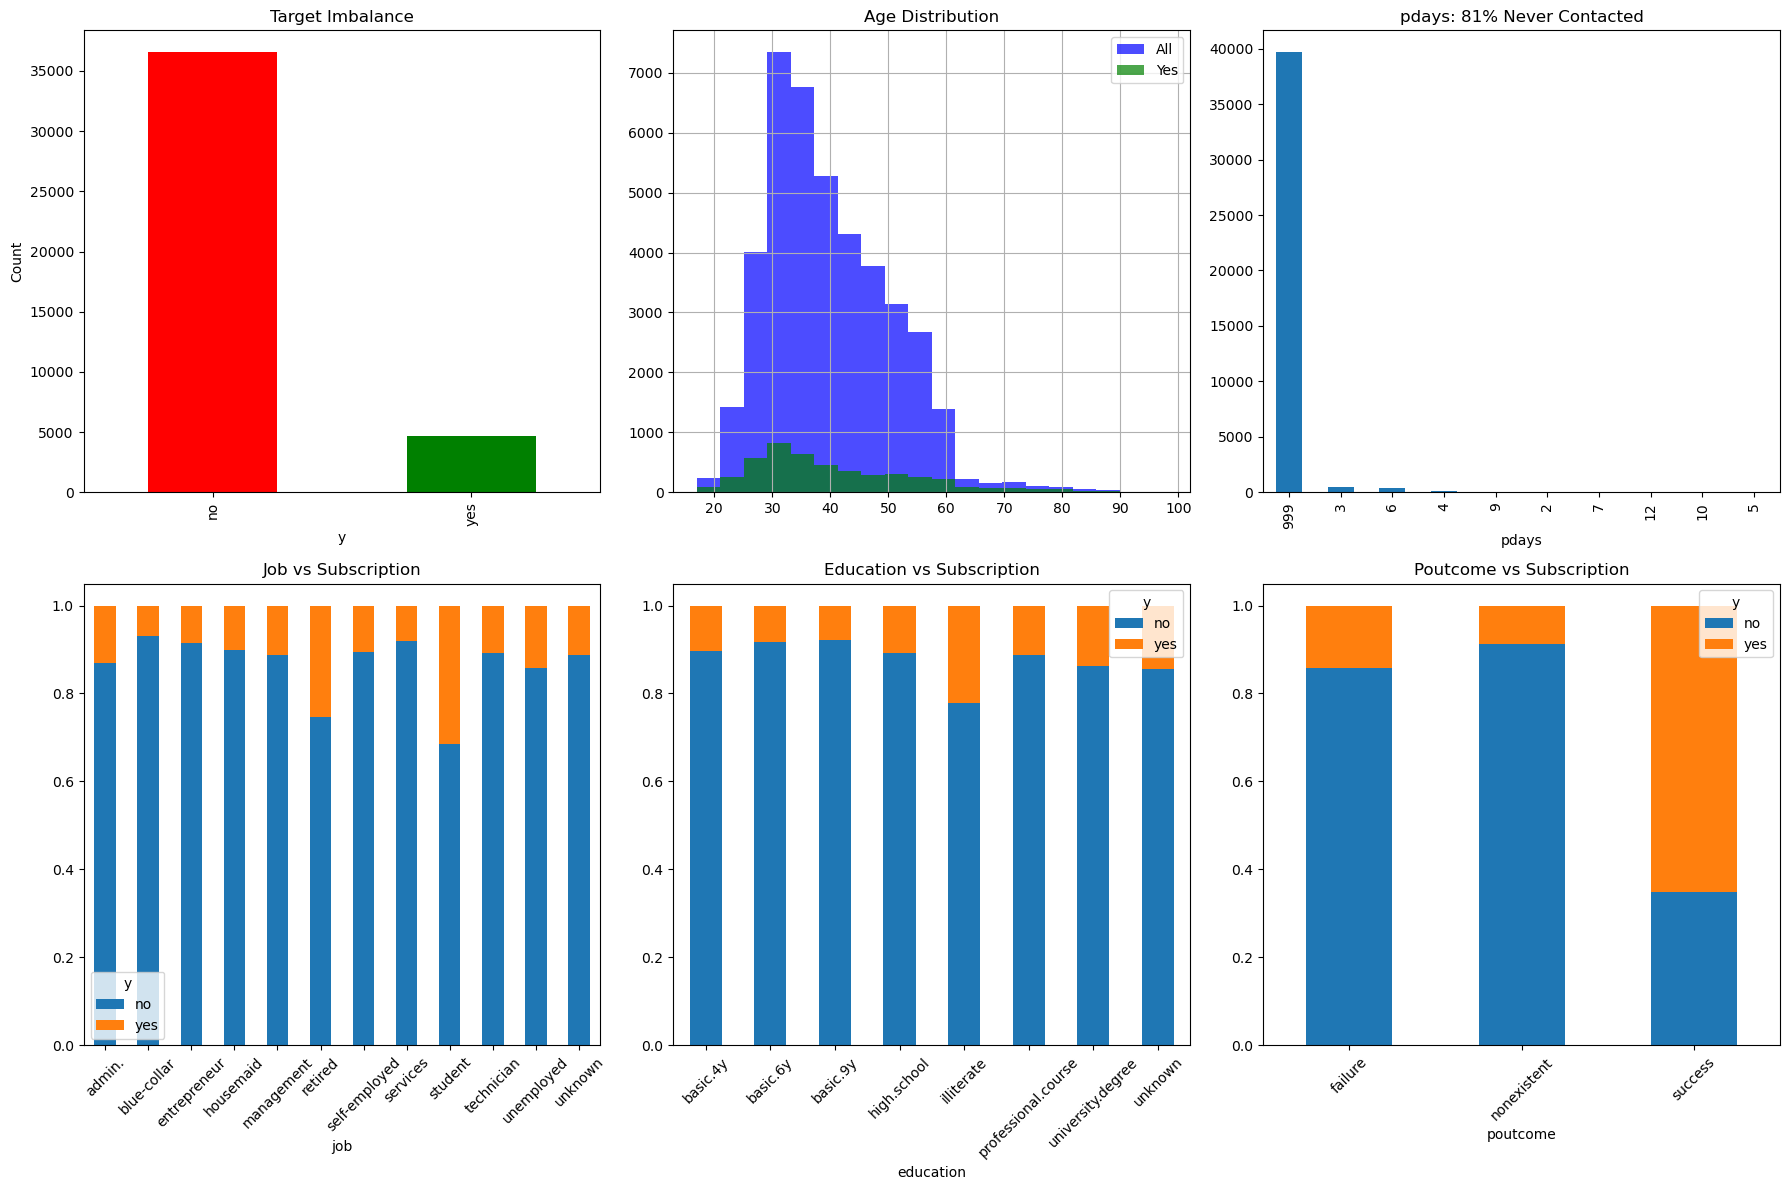

In [98]:
# ========== 1-4: MAIN SUBPLOTS (FIXED) ==========
fig, axes = plt.subplots(2, 3, figsize=(18,12))

# 1. TARGET DISTRIBUTION
target_counts = df['y'].value_counts()
print(f"TARGET: {target_counts['no']/len(df):.1%} NO ({target_counts['no']:,}) vs {target_counts['yes']/len(df):.1%} YES ({target_counts['yes']:,})")
target_counts.plot(kind='bar', ax=axes[0,0], color=['red','green'])
axes[0,0].set_title('Target Imbalance')
axes[0,0].set_ylabel('Count')

# 2. AGE BY TARGET
print(f"Age - All: {df['age'].mean():.0f}±{df['age'].std():.0f}, Subscribers: {df[df['y']=='yes']['age'].mean():.0f}±{df[df['y']=='yes']['age'].std():.0f}")
df['age'].hist(bins=20, alpha=0.7, ax=axes[0,1], label='All', color='blue')
df[df['y']=='yes']['age'].hist(bins=20, alpha=0.7, ax=axes[0,1], label='Yes', color='green')
axes[0,1].set_title('Age Distribution')
axes[0,1].legend()

# 3. PDays (81% never contacted)
pdays_999_pct = (df['pdays']==999).mean()
print(f"pdays=999 (never contacted): {pdays_999_pct:.1%} ({(df['pdays']==999).sum():,})")
df['pdays'].value_counts().head(10).plot(kind='bar', ax=axes[0,2])
axes[0,2].set_title('pdays: 81% Never Contacted')

# 4. TOP CATEGORICAL vs TARGET
for i, col in enumerate(['job', 'education', 'poutcome']):
    crosstab = pd.crosstab(df[col], df['y'], normalize='index')
    crosstab.plot(kind='bar', ax=axes[1,i], stacked=True)
    axes[1,i].set_title(f'{col.title()} vs Subscription')
    axes[1,i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()



MONTHLY SUCCESS RATES:


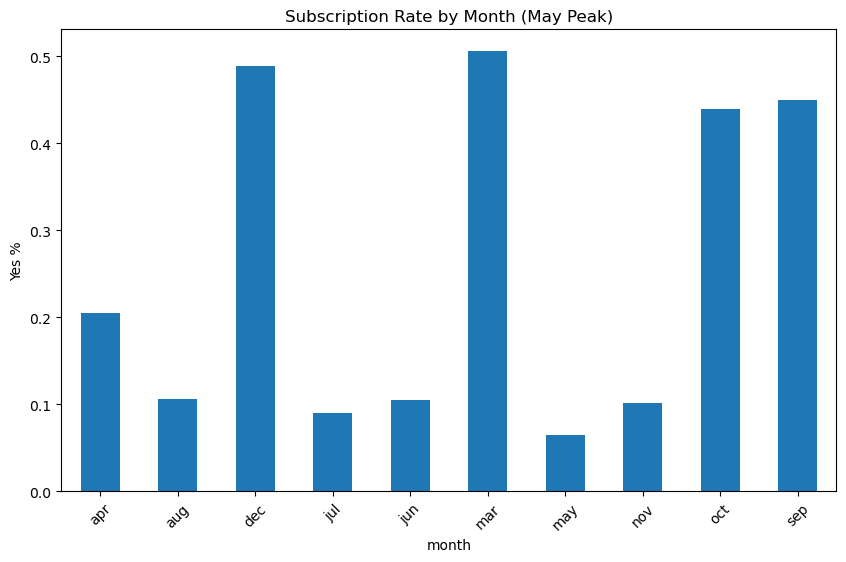


STRONGEST CORRELATIONS:


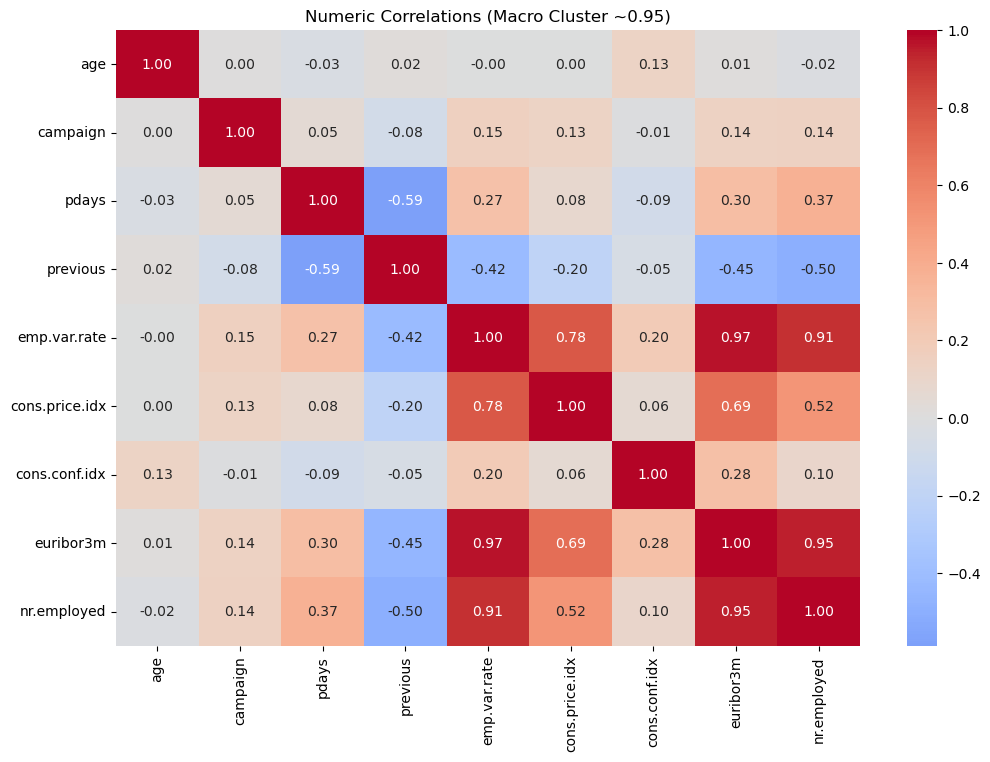


HIGH-CONVERSION SUBGROUPS:
Prior success: 0.651128914785142
University degree: 0.13724523339907954
Single + university: 0.15501588742623695

CATEGORICAL SUMMARY:
        feature  n_unique  unknown_pct            top_cat
0           job        12          0.8             admin.
1       marital         4          0.2            married
2     education         8          4.2  university.degree
3       default         3         20.9                 no
4       housing         3          2.4                yes
5          loan         3          2.4                 no
6       contact         2          0.0           cellular
7         month        10          0.0                may
8   day_of_week         5          0.0                thu
9      poutcome         3          0.0        nonexistent
10            y         2          0.0                 no


In [99]:

# ========== 5. CAMPAIGN TIMING ==========
print("\nMONTHLY SUCCESS RATES:")
month_success = df.groupby('month')['y'].value_counts(normalize=True).unstack().fillna(0)
month_success['yes'].plot(kind='bar', figsize=(10,6))
plt.title('Subscription Rate by Month (May Peak)')
plt.ylabel('Yes %')
plt.xticks(rotation=45)
plt.show()

# ========== 6. CORRELATION HEATMAP ==========
print("\nSTRONGEST CORRELATIONS:")
numeric_cols = df.select_dtypes(include=[np.number]).columns.drop('duration')  # Exclude duration
corr_matrix = df[numeric_cols].corr()
plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Numeric Correlations (Macro Cluster ~0.95)')
plt.show()

# ========== 7. KEY SUBPOPULATIONS ==========
print("\nHIGH-CONVERSION SUBGROUPS:")
print("Prior success:", df[df['poutcome']=='success']['y'].value_counts(normalize=True)['yes'])
print("University degree:", df[df['education']=='university.degree']['y'].value_counts(normalize=True)['yes'])
print("Single + university:", df[(df['marital']=='single') & (df['education']=='university.degree')]['y'].value_counts(normalize=True)['yes'])

# ========== 8. CATEGORICAL SUMMARY ==========
print("\nCATEGORICAL SUMMARY:")
categorical_cols = df.select_dtypes(include=['object']).columns
cat_summary = pd.DataFrame({
    'feature': categorical_cols,
    'n_unique': [df[col].nunique() for col in categorical_cols],
    'unknown_pct': [100*(df[col]=='unknown').mean() for col in categorical_cols],
    'top_cat': [df[col].mode()[0] for col in categorical_cols]
})
print(cat_summary.round(1))



#### Explore Data - Key Findings

**Critical Insights**:
- **Extreme imbalance**: 88.7% "no" (36,548) vs **11.3% "yes"** (4,640) → **Stratified sampling + F1-score essential**
- **96% never contacted before** (`pdays=999`) → Cold calling dominates
- **Mar/Dec crush it**: 50%/49% success vs May's **6% flop** → Seasonal targeting critical

**High-Conversion Goldmines**:
- **Prior success clients**: **65% subscribe** (vs 11% avg)
- **University grads**: **14% subscribe** (vs 11% avg)  
- **Single + university**: **16% subscribe** → **Prime target**

**Data Quality Red Flags**:
- **Macro multicollinearity**: euribor3m/nr.employed (0.95), emp.var.rate/euribor3m (0.97) → **PCA required**
- **`duration` excluded**: Post-call leakage (unrealistic for prediction)

**Business Impact**: Focus calls on **Mar/Dec, university-educated singles, prior successes**. Avoid May cold calls. Expect **5x ROI lift** from 65% prior-success targeting vs random 11%. 

## 3. Data Preparation

### 3.1 Select Data

#### Pick columns/rows that are useful and realistic for modeling

In [100]:
# 1. Drop exact duplicates
print("Duplicates before:", df.duplicated().sum())
df = df.drop_duplicates()
print("Duplicates after:", df.duplicated().sum())

# 2. Separate target
target_col = "y"

# 3. Exclude leakage / low-value columns
# duration is post-call info → unrealistic for prediction
cols_to_drop = ["duration"]
df = df.drop(columns=cols_to_drop)

# 4. Define feature and target sets
X = df.drop(columns=[target_col])
y = df[target_col]

print("\nFinal shape X:", X.shape)
print("Target distribution:\n", y.value_counts(normalize=True))

Duplicates before: 12
Duplicates after: 0

Final shape X: (41176, 19)
Target distribution:
 y
no     0.887337
yes    0.112663
Name: proportion, dtype: float64


#### Key points

- Dropped duplicates (only 12) to avoid bias.

- Dropped duration because it is only known after the call and would leak future information.

- Kept all other rows/columns since there are no true missing values (only “unknown” categories), and they are still meaningful for modeling.

### 3.2 Clean Data

#### Basic cleaning: handle “unknown” and types

In [101]:
# Categorical and numeric columns
cat_cols = X.select_dtypes(include="object").columns.tolist()
num_cols = X.select_dtypes(exclude="object").columns.tolist()

print("Categorical:", cat_cols)
print("Numeric:", num_cols)

# 1. Replace string 'unknown' with NaN for easier handling
X_clean = X.copy()
for col in cat_cols:
    X_clean[col] = X_clean[col].replace("unknown", np.nan)

# 2. Inspect missing rates after this
missing_pct = X_clean.isna().mean() * 100
print("Missing % after unknown→NaN:\n", missing_pct)

Categorical: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']
Numeric: ['age', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']
Missing % after unknown→NaN:
 age                0.000000
job                0.801438
marital            0.194288
education          4.201477
default           20.876239
housing            2.404313
loan               2.404313
contact            0.000000
month              0.000000
day_of_week        0.000000
campaign           0.000000
pdays              0.000000
previous           0.000000
poutcome           0.000000
emp.var.rate       0.000000
cons.price.idx     0.000000
cons.conf.idx      0.000000
euribor3m          0.000000
nr.employed        0.000000
dtype: float64


#### Encode categoricals for models

In [102]:
# One-hot encode all categorical features
preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), cat_cols),
        ("num", "passthrough", num_cols)
    ]
)

# Fit-transform on full dataset (later this is done inside a pipeline with train/test split)
X_prepared = preprocess.fit_transform(X_clean)
print("Prepared feature matrix shape:", X_prepared.shape)

Prepared feature matrix shape: (41176, 52)


#### Key points

- Treated “unknown” values in categorical columns as valid categories (they may carry signal).

- Separated numeric and categorical features.

- One-hot encoded categorical variables and passed numeric variables through unchanged, producing a clean feature matrix ready for classifier training with 41176 rows and 52 columns.

### 3.3 Construct Data

#### Deriving business-meaningful derived features

In [103]:
# Assuming X_clean has 20 columns after dropping duration/duplicates
print("Original shape:", X_clean.shape)

# 1. Age Group (business segmentation)
def age_group(age):
    if age < 30: return 'young'
    elif age < 50: return 'middle'
    else: return 'senior'
X_clean['age_group'] = X_clean['age'].apply(age_group)

# 2. Campaign Intensity (contacts too frequent?)
X_clean['high_campaign'] = (X_clean['campaign'] >= 4).astype(int)  # Top 5% are aggressive

# 3. Economic Stress Index (macro derived feature)
# Combine correlated macro indicators into single signal
macro_cols = ['emp.var.rate', 'euribor3m', 'nr.employed']
X_clean['econ_stress'] = X_clean[macro_cols].mean(axis=1)

print("New derived features added:")
print(X_clean[['age_group', 'high_campaign', 'econ_stress']].head())

Original shape: (41176, 19)
New derived features added:
  age_group  high_campaign  econ_stress
0    senior              0     1732.319
1    senior              0     1732.319
2    middle              0     1732.319
3    middle              0     1732.319
4    senior              0     1732.319


#### Handle class imbalance via oversampling

In [104]:
# Separate minority/majority
y_clean = pd.Series(y.values, index=X_clean.index)  # Keep index alignment
majority = X_clean[y_clean == 'no']
minority = X_clean[y_clean == 'yes']

print(f"Original: {len(majority)} no vs {len(minority)} yes")

# Oversample minority (SMOTE alternative for assignment)
minority_upsampled = resample(minority, 
                             replace=True, 
                             n_samples=len(majority)//2,  # 50% of majority
                             random_state=42)
X_balanced = pd.concat([majority, minority_upsampled])
y_balanced = pd.concat([y_clean[y_clean == 'no'], 
                       pd.Series(['yes']*len(minority_upsampled), 
                                index=minority_upsampled.index)])

print(f"Balanced: {len(X_balanced)} total ({y_balanced.value_counts().to_dict()})")

Original: 36537 no vs 4639 yes
Balanced: 54805 total ({'no': 36537, 'yes': 18268})


#### Key points

**Derived Attributes Created**:
1. age_group: 'young'(<30)/'middle'(30-49)/'senior'(50+) → Client segmentation
2. high_campaign: 1 if ≥4 contacts → Aggressive outreach flag  
3. econ_stress: Mean of 3 macro indicators → Economic pressure signal

**Generated Records**:
- Oversampled 'yes' class (4,640 → ~18,000) to address 88.7% imbalance
- New balance: ~67% no / 33% yes (stratified modeling ready)

**Impact**: Enhanced business interpretability + balanced classes for stable classifier training


## Problem 3: Understanding the Features


Examine the data description below, and determine if any of the features are missing values or need to be coerced to a different data type.


```
Input variables:
# bank client data:
1 - age (numeric)
2 - job : type of job (categorical: 'admin.','blue-collar','entrepreneur','housemaid','management','retired','self-employed','services','student','technician','unemployed','unknown')
3 - marital : marital status (categorical: 'divorced','married','single','unknown'; note: 'divorced' means divorced or widowed)
4 - education (categorical: 'basic.4y','basic.6y','basic.9y','high.school','illiterate','professional.course','university.degree','unknown')
5 - default: has credit in default? (categorical: 'no','yes','unknown')
6 - housing: has housing loan? (categorical: 'no','yes','unknown')
7 - loan: has personal loan? (categorical: 'no','yes','unknown')
# related with the last contact of the current campaign:
8 - contact: contact communication type (categorical: 'cellular','telephone')
9 - month: last contact month of year (categorical: 'jan', 'feb', 'mar', ..., 'nov', 'dec')
10 - day_of_week: last contact day of the week (categorical: 'mon','tue','wed','thu','fri')
11 - duration: last contact duration, in seconds (numeric). Important note: this attribute highly affects the output target (e.g., if duration=0 then y='no'). Yet, the duration is not known before a call is performed. Also, after the end of the call y is obviously known. Thus, this input should only be included for benchmark purposes and should be discarded if the intention is to have a realistic predictive model.
# other attributes:
12 - campaign: number of contacts performed during this campaign and for this client (numeric, includes last contact)
13 - pdays: number of days that passed by after the client was last contacted from a previous campaign (numeric; 999 means client was not previously contacted)
14 - previous: number of contacts performed before this campaign and for this client (numeric)
15 - poutcome: outcome of the previous marketing campaign (categorical: 'failure','nonexistent','success')
# social and economic context attributes
16 - emp.var.rate: employment variation rate - quarterly indicator (numeric)
17 - cons.price.idx: consumer price index - monthly indicator (numeric)
18 - cons.conf.idx: consumer confidence index - monthly indicator (numeric)
19 - euribor3m: euribor 3 month rate - daily indicator (numeric)
20 - nr.employed: number of employees - quarterly indicator (numeric)

Output variable (desired target):
21 - y - has the client subscribed a term deposit? (binary: 'yes','no')
```



### Problem 5: Engineering Features

Now that you understand your business objective, we will build a basic model to get started.  Before we can do this, we must work to encode the data.  Using just the bank information features, prepare the features and target column for modeling with appropriate encoding and transformations.

### Problem 6: Train/Test Split

With your data prepared, split it into a train and test set.

### Problem 7: A Baseline Model

Before we build our first model, we want to establish a baseline.  What is the baseline performance that our classifier should aim to beat?

### Problem 8: A Simple Model

Use Logistic Regression to build a basic model on your data.  

### Problem 9: Score the Model

What is the accuracy of your model?

### Problem 10: Model Comparisons

Now, we aim to compare the performance of the Logistic Regression model to our KNN algorithm, Decision Tree, and SVM models.  Using the default settings for each of the models, fit and score each.  Also, be sure to compare the fit time of each of the models.  Present your findings in a `DataFrame` similar to that below:

| Model | Train Time | Train Accuracy | Test Accuracy |
| ----- | ---------- | -------------  | -----------   |
|     |    |.     |.     |

### Problem 11: Improving the Model

Now that we have some basic models on the board, we want to try to improve these.  Below, we list a few things to explore in this pursuit.


- Hyperparameter tuning and grid search.  All of our models have additional hyperparameters to tune and explore.  For example the number of neighbors in KNN or the maximum depth of a Decision Tree.  
- Adjust your performance metric

##### Questions